In [ ]:
#Standard Packages:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime
from dateutil.relativedelta import relativedelta
from pandas.tseries.offsets import MonthEnd

#YahooFinance:
from pandas_datareader import data as pdr
import yfinance as yf


#Statsmodels:
import statsmodels.api as sma
import statsmodels as sm
from statsmodels import tsa
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import jarque_bera
from scipy.stats import t, probplot

In [ ]:
#Importing historic price data using yfinance
ticker = 'BMRI.JK'
stockTicker = yf.Ticker(ticker)
hist = stockTicker.history(period='1y')

#For forecasting purposes I reset my index to integers:
hist = hist.reset_index()

In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(x = hist.index, y = hist['Close'], mode = 'lines'))

fig.update_layout(
    autosize=False,
    width=800,
    height=500,
    xaxis_title = 'Days',
    yaxis_title = 'Price $',
    title = f'{ticker} Historic Stock Price'
)

fig.show()

In [ ]:
#Order of integration
adf = adfuller(x=hist['Close'],
                  autolag='BIC')
print(f'ADF Statistic: {adf[0]}')
print(f'p-value: {adf[1]}')

ADF Statistic: -3.075107337830414
p-value: 0.02845104721534748


In [ ]:
# Membuat kolom baru berisi selisih harga (differencing)
hist['Diff_1'] = hist['Close']

# Uji kembali dengan ADF pada data yang sudah di-diff
adf_diff = adfuller(hist['Diff_1'].dropna(), autolag='BIC')

print(f'ADF Statistic (Setelah Diff): {adf_diff[0]}')
print(f'p-value (Setelah Diff): {adf_diff[1]}')

ADF Statistic (Setelah Diff): -3.075107337830414
p-value (Setelah Diff): 0.02845104721534748


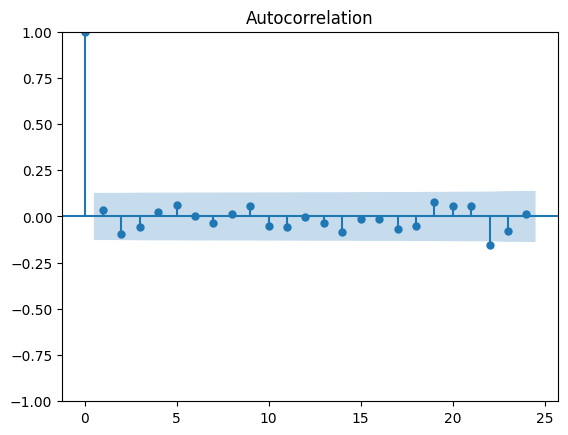

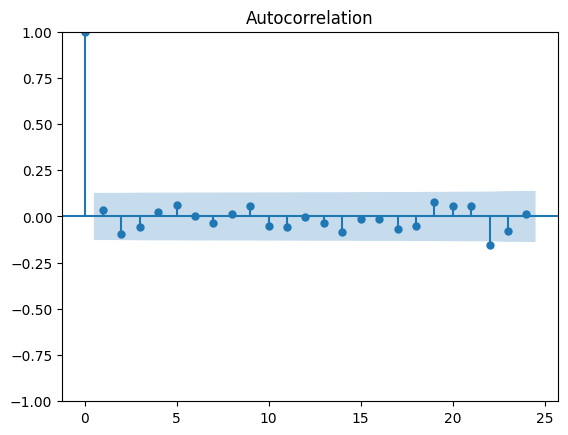

In [ ]:
# Gunakan .diff() dan .dropna() agar data stasioner
sma.graphics.tsa.plot_acf(hist['Close'].diff().dropna())

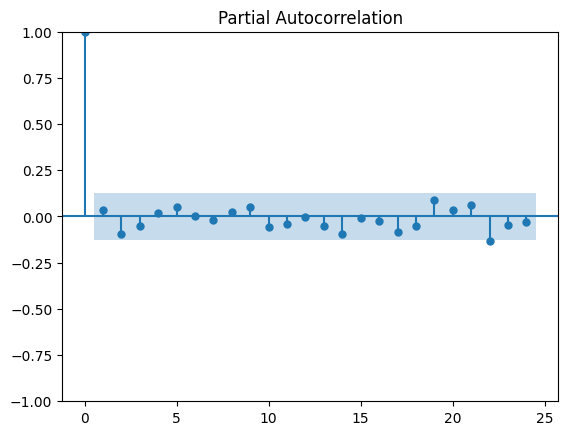

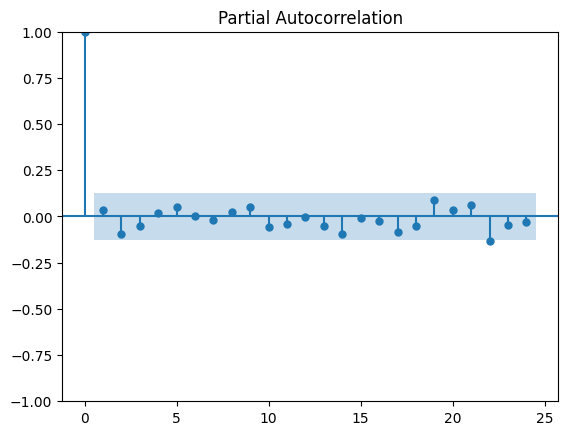

In [ ]:
# Plot PACF pada data yang sudah stasioner
sma.graphics.tsa.plot_pacf(hist['Close'].diff().dropna())

In [ ]:
#Significant AR lags:
pacf_coef = pacf(hist['Close'].diff().dropna(), alpha=.05)
sig_pacf = []
for i in range(1, len(pacf_coef[0])):
    if pacf_coef[0][i] > (pacf_coef[1][i][1] - pacf_coef[0][i]):
        sig_pacf.append(i)
    elif pacf_coef[0][i] < (pacf_coef[1][i][0] - pacf_coef[0][i]):
        sig_pacf.append(i)

sig_pacf

[22]

In [ ]:
def get_arima_price(df, fact, forecast_steps):

    #MA Lags
    acf_coef = acf(df[fact].diff().dropna(), alpha=.05)
    sig_acf = []
    for i in range(1, len(acf_coef[0])):
        if acf_coef[0][i] > (acf_coef[1][i][1] - acf_coef[0][i]):
            sig_acf.append(i)
        elif acf_coef[0][i] < (acf_coef[1][i][0] - acf_coef[0][i]):
            sig_acf.append(i)

    #AR Lags
    pacf_coef = pacf(df[fact].diff().dropna(), alpha=.05)
    sig_pacf = []
    for i in range(1, len(pacf_coef[0])):
        if pacf_coef[0][i] > (pacf_coef[1][i][1] - pacf_coef[0][i]):
            sig_pacf.append(i)
        elif pacf_coef[0][i] < (pacf_coef[1][i][0] - pacf_coef[0][i]):
            sig_pacf.append(i)

    #Order of integration
    adf = adfuller(x=df[fact],
                  autolag='BIC')
    order = 0
    if adf[0] < adf[4]['5%']:
        order = 0
    else:
        order = 1

    #Trend indication
    if order == 1:
        trend = 't'
    else:
        trend = 'c'
    # Ambil nilai maksimal agar menjadi integer
    p = max(sig_pacf) if sig_pacf else 0
    q = max(sig_acf) if sig_acf else 0
    d = order # hasil dari pengecekan ADF

    model = ARIMA(endog = df[fact],
                  order = (p, d, q),
                  trend = trend).fit()

    forecast = model.get_forecast(forecast_steps, alpha=0.05)

    predict = model.predict()

    return forecast.summary_frame(), model.summary(), predict

In [ ]:
# Mencoba prediksi untuk 30 hari ke depan
hasil_forecast, ringkasan, hasil_predict = get_arima_price(hist, 'Close', 30)

# Intip hasil prediksinya
print(hasil_forecast)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



Close         mean     mean_se  mean_ci_lower  mean_ci_upper
237    3470.496892   60.387558    3352.139452    3588.854331
238    3523.838130   85.295263    3356.662486    3691.013774
239    3543.282722  100.573447    3346.162389    3740.403055
240    3623.738901  111.742483    3404.727659    3842.750143
241    3668.019652  121.987183    3428.929166    3907.110138
242    3652.329996  131.298857    3394.988965    3909.671026
243    3607.543192  137.715051    3337.626652    3877.459731
244    3599.718337  141.281141    3322.812389    3876.624285
245    3625.130025  144.618569    3341.682838    3908.577212
246    3627.427893  149.035567    3335.323549    3919.532237
247    3654.380227  151.480319    3357.484258    3951.276196
248    3670.816663  152.467027    3371.986781    3969.646544
249    3689.575483  153.388414    3388.939716    3990.211250
250    3652.588362  153.702333    3351.337325    3953.839399
251    3694.770743  153.700086    3393.524110    3996.017375
252    3738.652011  153.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning:

Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.



In [ ]:
# 1. Jalankan fungsi untuk mendapatkan hasil
# Kita asumsikan memprediksi 30 hari ke depan
forecast_df, summary, predict_values = get_arima_price(hist, 'Close', 30)

# 2. Buat grafik perbandingan
fig = go.Figure()

# Garis Harga Asli
fig.add_trace(go.Scatter(
    x=hist['Date'],
    y=hist['Close'],
    mode='lines',
    name='Harga Asli (Actual)',
    line=dict(color='blue')
))

# Garis Prediksi pada data historis (In-sample prediction)
fig.add_trace(go.Scatter(
    x=hist['Date'],
    y=predict_values,
    mode='lines',
    name='Prediksi Model (In-sample)',
    line=dict(color='orange', dash='dot')
))

# Garis Peramalan Masa Depan (Out-of-sample forecast)
# Kita buat index tanggal untuk masa depan
last_date = hist['Date'].iloc[-1]
forecast_dates = [last_date + relativedelta(days=i) for i in range(1, 31)]

fig.add_trace(go.Scatter(
    x=forecast_dates,
    y=forecast_df['mean'],
    mode='lines',
    name='Ramalan 30 Hari (Forecast)',
    line=dict(color='red', width=3)
))

# Menambahkan Area Ketidakpastian (Confidence Interval)
fig.add_trace(go.Scatter(
    x=forecast_dates + forecast_dates[::-1],
    y=pd.concat([forecast_df['mean_ci_upper'], forecast_df['mean_ci_lower'][::-1]]),
    fill='toself',
    fillcolor='rgba(255, 0, 0, 0.1)',
    line=dict(color='rgba(255, 0, 0, 0)'),
    hoverinfo="skip",
    showlegend=True,
    name='Batas Ketidakpastian'
))

fig.update_layout(
    title='Analisis Prediksi Harga Saham BMRI.JK (Model ARIMA)',
    xaxis_title='Tanggal',
    yaxis_title='Harga (IDR)',
    template='plotly_white',
    hovermode='x unified'
)

fig.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning:

Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.



In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(x = hist.index, y = hist['Close'], mode = 'lines', name = 'Observed'))
fig.add_trace(go.Scatter(x = hasil_predict.index[1:], y = hasil_predict[1:], mode = 'lines', name = 'ARIMA Model Prediction'))
fig.add_trace(go.Scatter(x = forecast_df.index, y = forecast_df['mean'], mode = 'lines', name = 'ARIMA Model Forecast'))
fig.add_trace(go.Scatter(x = forecast_df.index, y = forecast_df['mean_ci_lower'], mode = 'lines', name = 'Forecast Error', line=dict(color='darkblue')))
fig.add_trace(go.Scatter(x = forecast_df.index, y = forecast_df['mean_ci_upper'], mode = 'lines', line=dict(color='darkblue'), showlegend = False))
fig.add_trace(go.Scatter(x = [hasil_predict.index[-1], forecast_df.index[0]], y = [hasil_predict.iloc[-1], forecast_df['mean'].iloc[0]], mode = 'lines', name = 'ARIMA Model 1-Day Forecast'))
fig.add_trace(go.Scatter(x = forecast_df.index[:4], y = forecast_df['mean'].iloc[:4], mode = 'lines', name = 'ARIMA Model 4-Day Forecast (Higher Accuracy)'))

fig.update_layout(
    autosize=False,
    width=800,
    height=500,
    xaxis_title = 'Days',
    yaxis_title = 'Price $',
    title = f'{ticker} Stock Price'
)

fig.show()

In [ ]:
print(hasil_forecast['mean'])

237    3470.496892
238    3523.838130
239    3543.282722
240    3623.738901
241    3668.019652
242    3652.329996
243    3607.543192
244    3599.718337
245    3625.130025
246    3627.427893
247    3654.380227
248    3670.816663
249    3689.575483
250    3652.588362
251    3694.770743
252    3738.652011
253    3747.117133
254    3775.855148
255    3753.514096
256    3739.545688
257    3738.442449
258    3759.875402
259    3765.109545
260    3754.190775
261    3779.583427
262    3780.328630
263    3768.289837
264    3776.871751
265    3816.474767
266    3805.940579
Name: mean, dtype: float64


In [ ]:
# 1. Simpan tabel forecast ke dalam file CSV
# Kita ambil hasil dari variabel forecast_df yang berisi mean dan confidence interval
forecast_df.to_excel('hasil_prediksi_arima_bmri.xlsx', index=True)

# 2. Perintah untuk mengunduh file ke komputer lokal (khusus Google Colab)
from google.colab import files
files.download('hasil_prediksi_arima_bmri.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 1. Ambil hanya kolom 'mean' saja
prediksi_hanya_mean = hasil_forecast[['mean']]

# 2. Simpan ke file XLSX
file_output = 'prediksi_mean_bmri.xlsx'
prediksi_hanya_mean.to_excel(file_output, index=True)

# 3. Download file ke komputer lokal
from google.colab import files
files.download(file_output)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 1. Pastikan library openpyxl terinstal (untuk menulis file Excel)
!pip install openpyxl

# Hapus informasi timezone dari kolom 'Date'
hist['Date'] = hist['Date'].dt.tz_localize(None)

# 2. Simpan data 'hist' ke dalam format Excel
file_excel = f"{ticker}_data_historis_1y.xlsx"
hist.to_excel(file_excel, index=False)

# 3. Download file ke komputer lokal
from google.colab import files
files.download(file_excel)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>